# 02 — Exploratory Data Analysis (EDA)
Phase 3 of the project: relationships between fraud status and claim amount, policy tenure, premium, incident/accident characteristics, demographics, and policy features.

For every finding: (1) state the observation, (2) give the business interpretation, (3) explicitly separate correlation from causation.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import load_raw_data, basic_clean, encode_target

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = load_raw_data('../data/raw/insurance_claims.csv')
df = basic_clean(df)
df_enc = encode_target(df)
df.shape

(1000, 39)

## Correlation matrix — numeric features

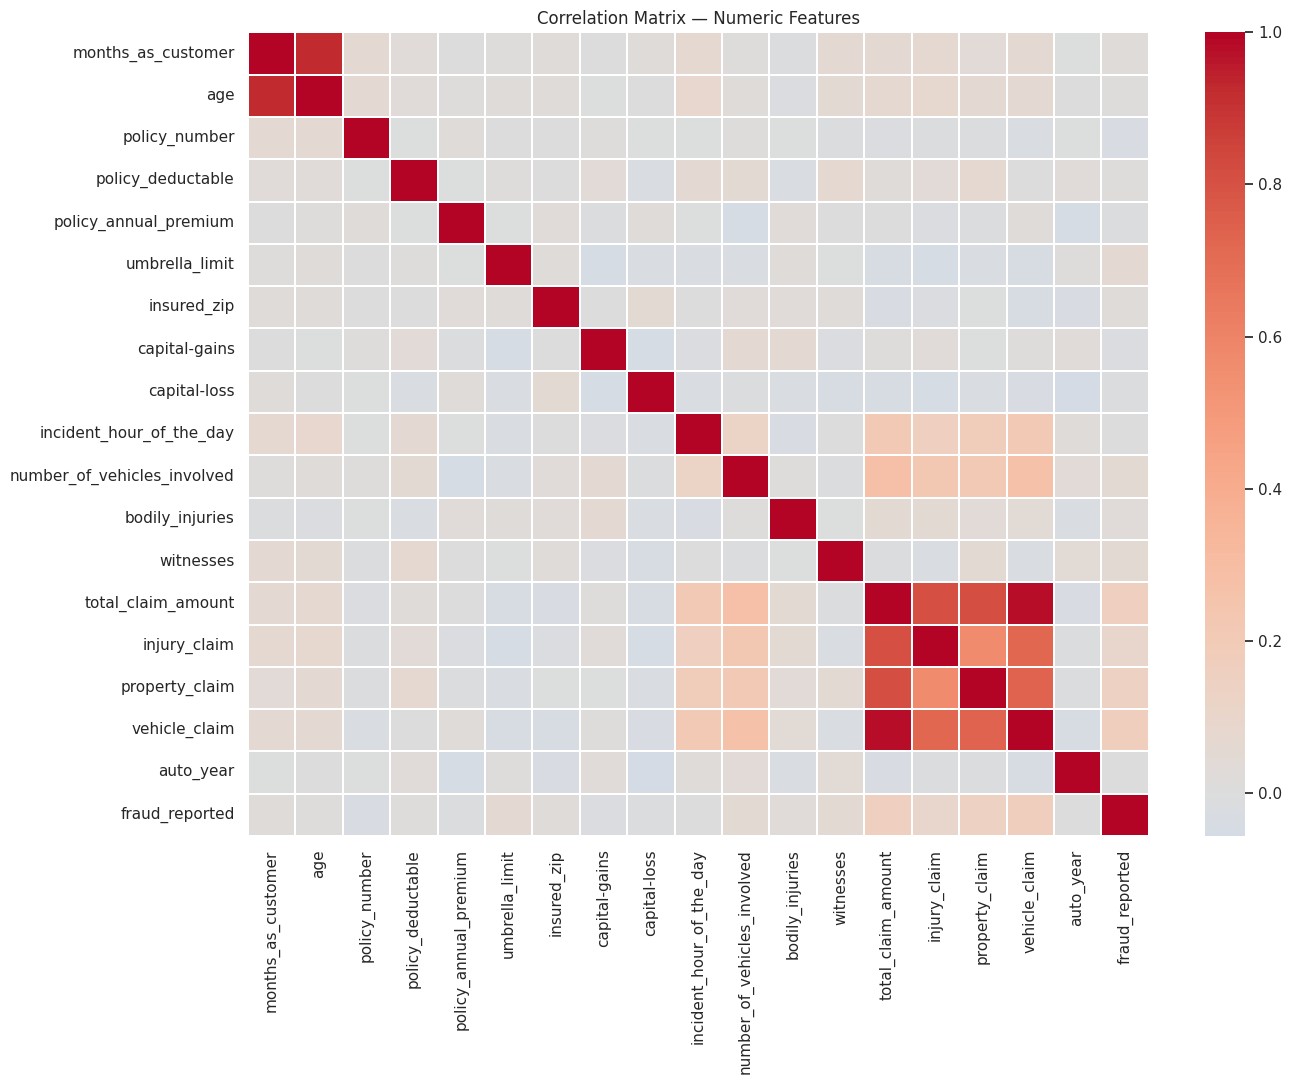

Correlation of each numeric feature with fraud_reported (sorted by |r|):


vehicle_claim                  0.170049
total_claim_amount             0.163651
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058622
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
policy_number                 -0.029443
months_as_customer             0.020544
Name: fraud_reported, dtype: float64

In [2]:
numeric_df = df_enc.select_dtypes(include=[np.number])
corr = numeric_df.corr()
fig, ax = plt.subplots(figsize=(14,11))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, linewidths=0.3)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout(); plt.show()

print("Correlation of each numeric feature with fraud_reported (sorted by |r|):")
corr['fraud_reported'].drop('fraud_reported').sort_values(key=abs, ascending=False).head(10)

**Observation:** the raw linear correlations between numeric features and `fraud_reported` are all weak (|r| < 0.2) — `vehicle_claim`, `total_claim_amount`, and `property_claim` are the strongest, all positive but modest.

**Business interpretation:** no single numeric variable is a strong linear fraud predictor on its own. This suggests fraud signal in this dataset is carried more by **categorical/contextual patterns** (e.g. incident severity, specific hobbies) and by **interactions** between variables than by simple linear relationships — which is exactly the kind of pattern tree-based ML models are suited to capture and linear correlation analysis alone would miss.

**Correlation vs. causation:** none of this implies any of these variables *cause* fraud. Higher claim amounts are correlated with fraud in this sample, but that could reflect a genuine tendency to inflate large claims, or could be a data-generation artifact — we cannot distinguish the two from observational data alone.

## Claim amount vs. fraud status

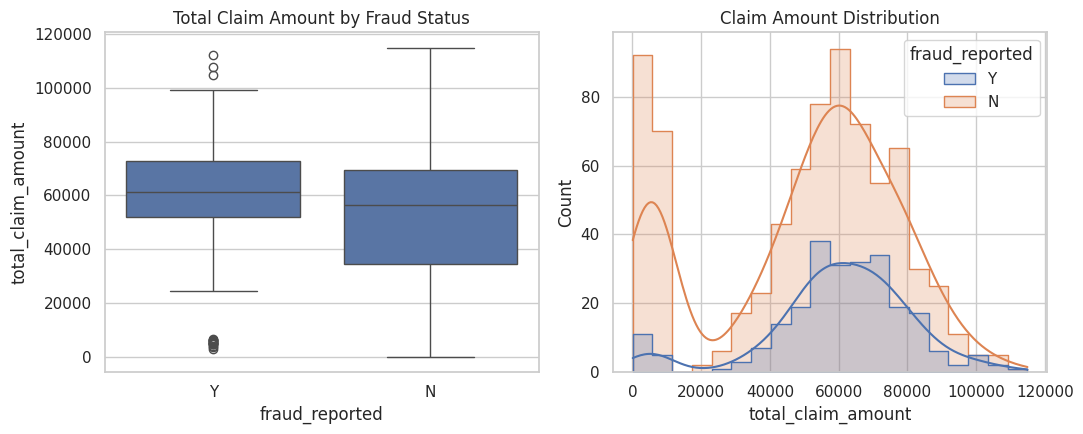

                count          mean           std     min      25%      50%  \
fraud_reported                                                                
N               753.0  50288.605578  27575.191379   100.0  34650.0  56520.0   
Y               247.0  60302.105263  20746.279567  2860.0  51910.0  61290.0   

                    75%       max  
fraud_reported                     
N               69480.0  114920.0  
Y               72665.0  112320.0  


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df, ax=axes[0])
axes[0].set_title('Total Claim Amount by Fraud Status')
sns.histplot(data=df, x='total_claim_amount', hue='fraud_reported', kde=True, element='step', ax=axes[1])
axes[1].set_title('Claim Amount Distribution')
plt.tight_layout(); plt.show()

print(df.groupby('fraud_reported')['total_claim_amount'].describe())

**Observation:** fraudulent claims have a visibly higher median total claim amount than legitimate claims, though with heavy overlap in the distributions (many legitimate claims are also high-value).

**Business interpretation:** claim size alone is a weak-to-moderate discriminator — consistent with it being a common, if imperfect, informal red flag investigators already use. It should feed the model as one signal among many, not act as a standalone rule.

**Correlation vs. causation:** we cannot say large claims *cause* or *indicate* fraud in a deterministic sense — many large claims here are legitimate, and the direction of the relationship (does inflating claims lead to detection, or do fraudsters target already-large losses?) is not identifiable from this data.

## Incident severity vs. fraud rate

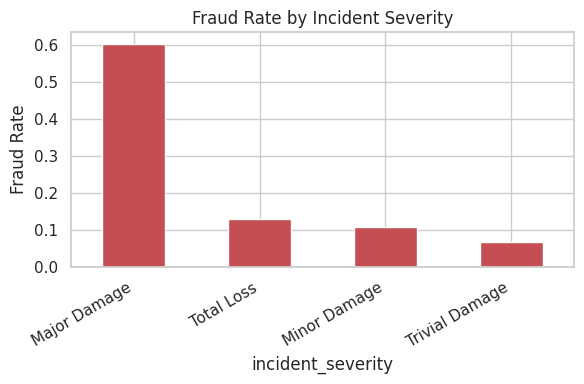

incident_severity
Major Damage      0.605072
Total Loss        0.128571
Minor Damage      0.107345
Trivial Damage    0.066667
Name: fraud_reported, dtype: float64

In [4]:
fraud_rate_severity = df.groupby('incident_severity')['fraud_reported'].apply(lambda x: (x=='Y').mean()).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
fraud_rate_severity.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_title('Fraud Rate by Incident Severity'); ax.set_ylabel('Fraud Rate')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
fraud_rate_severity

**Observation:** claims marked **"Major Damage" have a fraud rate of ~60%**, dramatically higher than Total Loss (~13%), Minor Damage (~11%), or Trivial Damage (~7%). This is the single strongest categorical signal found in the dataset.

**Business interpretation:** this is a striking pattern worth flagging to SIU — but a 60% fraud rate among "Major Damage" claims is unusually high for real-world fraud detection (typical industry fraud rates are in the low single digits to low teens). This magnitude is more consistent with a **synthetic/teaching dataset with a strong, deliberately-detectable pattern** than with real claims behavior, and should be treated as a modeling exercise finding rather than assumed to generalize to a real insurer's book.

**Correlation vs. causation:** "Major Damage" does not cause fraud; at most, severity classification could be one of several dimensions fraudsters manipulate, or the dataset's fraud labels may have been generated with a dependency on this field.

## Policy tenure vs. fraud

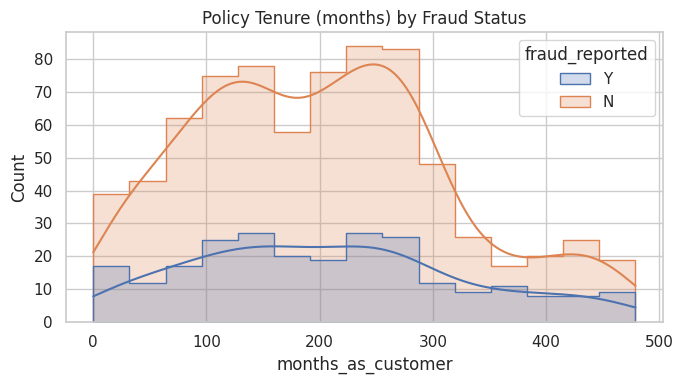

                count        mean         std  min    25%    50%    75%    max
fraud_reported                                                                
N               753.0  202.600266  113.574565  0.0  115.0  200.0  276.0  479.0
Y               247.0  208.080972  119.824064  3.0  116.0  199.0  279.0  478.0


In [5]:
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(data=df, x='months_as_customer', hue='fraud_reported', kde=True, element='step', ax=ax)
ax.set_title('Policy Tenure (months) by Fraud Status')
plt.tight_layout(); plt.show()

print(df.groupby('fraud_reported')['months_as_customer'].describe())

**Observation:** the tenure distributions for fraud vs. non-fraud claims are largely overlapping, with no dramatic shift toward newer customers among fraud cases in this dataset.

**Business interpretation:** the common assumption that fraud clusters among brand-new policyholders (premeditated fraud) is *not* strongly borne out here. This is a useful negative finding — it means tenure-based screening alone would not be an effective standalone fraud rule for this population, and the engineered `policy_tenure_days` feature (notebook 04) should be evaluated on its actual model contribution rather than assumed to matter.

**Correlation vs. causation:** tenure has no established causal relationship with fraud in this data; any weak pattern here can be explained by many uncontrolled factors (customer mix, policy type, geography).

## Demographics and policy characteristics — hobbies, occupation

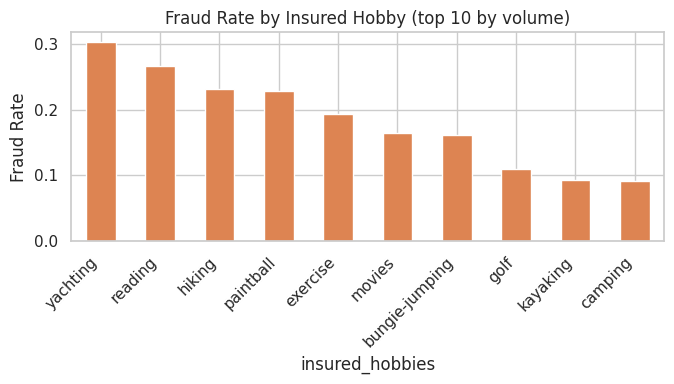

,fraud_rate,n
insured_hobbies,,
chess,0.826087,46
cross-fit,0.742857,35
yachting,0.301887,53
board-games,0.291667,48
polo,0.276596,47
reading,0.265625,64
base-jumping,0.265306,49
hiking,0.230769,52
paintball,0.228070,57


In [6]:
top_hobbies = df['insured_hobbies'].value_counts().head(10).index
sub = df[df['insured_hobbies'].isin(top_hobbies)]
fraud_rate_hobby = sub.groupby('insured_hobbies')['fraud_reported'].apply(lambda x: (x=='Y').mean()).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
fraud_rate_hobby.plot(kind='bar', ax=ax, color='#DD8452')
ax.set_title('Fraud Rate by Insured Hobby (top 10 by volume)'); ax.set_ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
fraud_rate_hobby

full_hobby_fraud = df.groupby('insured_hobbies')['fraud_reported'].agg(fraud_rate=lambda x:(x=='Y').mean(), n='count').sort_values('fraud_rate', ascending=False)
full_hobby_fraud.head(10)

**Observation:** a small number of hobbies (e.g. `chess`, `cross-fit` — visible in the full breakdown above once low-volume categories are included) show a much higher fraud rate than the ~25% baseline, well beyond what the other, higher-volume hobbies show.

**Business interpretation / important caution:** this is exactly the kind of pattern that must be treated carefully. Hobby is a **weak, non-causal proxy variable** — there is no plausible mechanism by which playing chess causes insurance fraud. A model that leans heavily on this feature (confirmed later in notebook 07's feature importance / SHAP analysis) is likely picking up a **dataset artifact** rather than a generalizable real-world fraud driver, and this is flagged explicitly in Phase 15 (Governance & Ethics) as a fairness/proxy-variable risk that should not be used to target individuals in a real deployment without further validation on real data.

**Correlation vs. causation:** hobby-fraud association here is correlational and very likely spurious/dataset-specific — not to be presented to investigators as a causal driver.

## Incident type, vehicles involved

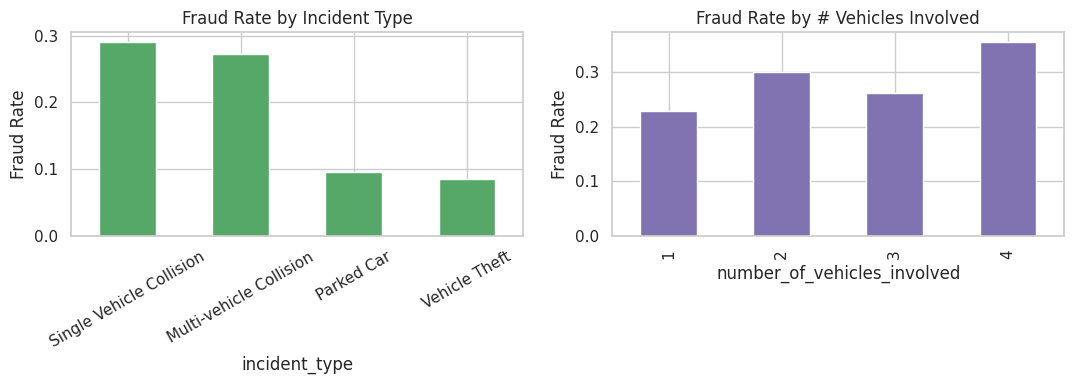

In [7]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
df.groupby('incident_type')['fraud_reported'].apply(lambda x:(x=='Y').mean()).sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].set_title('Fraud Rate by Incident Type'); axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=30)
df.groupby('number_of_vehicles_involved')['fraud_reported'].apply(lambda x:(x=='Y').mean()).plot(kind='bar', ax=axes[1], color='#8172B2')
axes[1].set_title('Fraud Rate by # Vehicles Involved'); axes[1].set_ylabel('Fraud Rate')
plt.tight_layout(); plt.show()

**Observation:** fraud rate varies by incident type, and claims with more vehicles involved don't show a simple monotonic fraud-rate trend.

**Business interpretation:** incident type is a plausible, explainable signal (e.g. vehicle theft claims are harder to independently verify than a witnessed multi-vehicle collision) and is retained as a modeling feature.

**Correlation vs. causation:** as with the other categorical breakdowns, these are descriptive associations in a sample of 1,000 claims, not causal claims.

## Phase 3 summary
- Numeric features show only weak linear correlation with fraud individually — signal is mostly categorical/contextual.
- `incident_severity` (especially "Major Damage") is by far the strongest single signal found — flagged as possibly dataset-specific in magnitude.
- Claim amount is a moderate, expected signal.
- Policy tenure shows little differentiation — a useful negative finding.
- Hobby shows a strong but very likely spurious association — explicitly flagged as a fairness/proxy-variable risk, not a claim of causation.

These findings directly motivate the feature engineering choices in notebook 04 and the fairness caveats revisited in notebook 07.